In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [2]:
california_housing = sklearn.datasets.fetch_california_housing(as_frame=True)

# firstly import all the dependencies

In [3]:
california_housing.data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
# Combine features and target into one DataFrame
df = california_housing.data
df['MedHouseVal'] = california_housing.target

# Display the full dataframe info and first few rows
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


None

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Data Description and Analysis
We will now look at the statistical distribution of the features and check for correlations with the target variable `MedHouseVal`.

In [5]:
# Statistical summary of all columns
display(df.describe())

# Calculate correlation with the target variable
correlations = df.corr()['MedHouseVal'].sort_values(ascending=False)
print("\nCorrelations with MedHouseVal:")
display(correlations)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



Correlations with MedHouseVal:


,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


Typically, for the California Housing dataset, **MedInc** (Median Income) is the most important column for predicting house prices, as it usually shows the highest positive correlation with the target value.

In [6]:
df.shape

(20640, 9)

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


### Correlation Heatmap
We use a heatmap to visualize the correlation matrix. This helps identify multicollinearity between features and their relationship with the target variable.

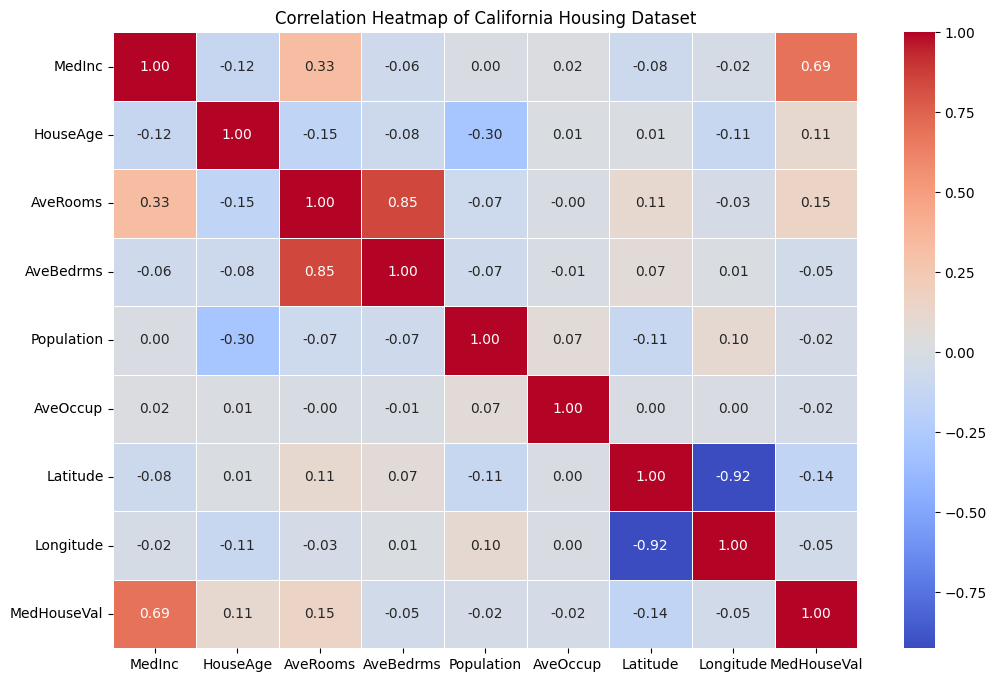

In [9]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of California Housing Dataset')
plt.show()

### Feature Selection
We will now extract the most important features. We'll keep `MedInc`, `HouseAge`, `AveRooms`, and the location data, while dropping the target from the feature set.

In [10]:
# Define features (X) and target (y)
# We drop MedHouseVal (target) and potentially highly collinear/low-impact features
# For this basic trim, we keep the main contributors.
X = df.drop(['MedHouseVal', 'AveBedrms'], axis=1)
y = df['MedHouseVal']

print("Selected Features:")
display(X.head())
print(f"\nFeature matrix shape: {X.shape}")

Selected Features:


,MedInc,HouseAge,AveRooms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,565.0,2.181467,37.85,-122.25



Feature matrix shape: (20640, 7)


### Train-Test Split
To evaluate our model's performance accurately, we must split the data into a training set and a testing set.

In [11]:
from sklearn.model_selection import train_test_split

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (16512, 7)
Testing set shape: (4128, 7)


Model Training

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Coefficients of model are:", model.coef_)
print("Intercept of model is:", model.intercept_)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

Coefficients of model are: [ 3.71939131e-01  9.79245076e-03  1.91164269e-02 -2.90695853e-06
 -3.23733409e-03 -4.57872368e-01 -4.64571653e-01]
Intercept of model is: -38.9758615951395
Mean Squared Error: 0.5473
Root Mean Squared Error: 0.7398
R^2 Score: 0.5823


In [22]:
# Calculate metrics for the training set to check for overfitting
y_train_pred = model.predict(X_train)

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print("--- Training Set Metrics ---")
print(f"RMSE: {rmse_train:.4f}")
print(f"R^2 Score: {r2_train:.4f}")

print("\n--- Test Set Metrics (from previous cell) ---")
print(f"RMSE: {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

--- Training Set Metrics ---
RMSE: 0.7317
R^2 Score: 0.5995

--- Test Set Metrics (from previous cell) ---
RMSE: 0.7398
R^2 Score: 0.5823


### Visualizing Model Performance
One of the best ways to see if a model is 'good' is to plot the actual prices against the predicted prices. If the model were perfect, all points would fall on the 45-degree line.

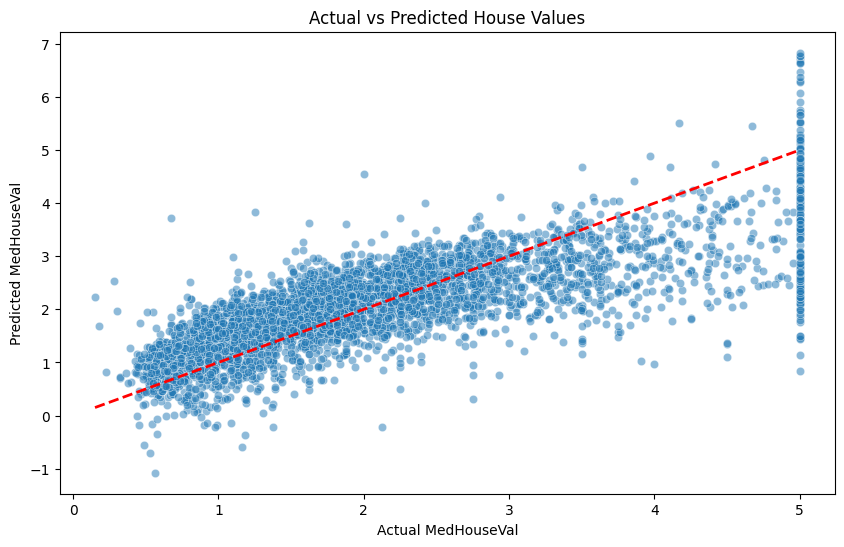

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Actual MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.title('Actual vs Predicted House Values')
plt.show()

### Plotting Actual vs. Actual
Per your request, here is the plot of the actual target values against themselves, which serves as the theoretical 'perfect prediction' line.

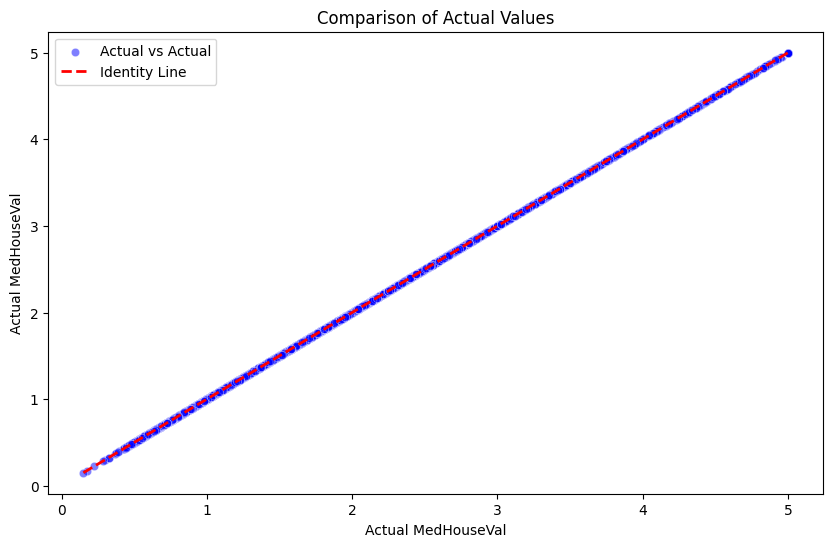

In [19]:
plt.figure(figsize=(10, 6))
# Plotting actual vs actual
sns.scatterplot(x=y_test, y=y_test, alpha=0.5, color='blue', label='Actual vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--', label='Identity Line')
plt.xlabel('Actual MedHouseVal')
plt.ylabel('Actual MedHouseVal')
plt.title('Comparison of Actual Values')
plt.legend()
plt.show()

### Residual Analysis
To finalize the evaluation, we check the residuals ($y_{test} - y_{pred}$). A good linear model should have residuals normally distributed around zero with no clear patterns.

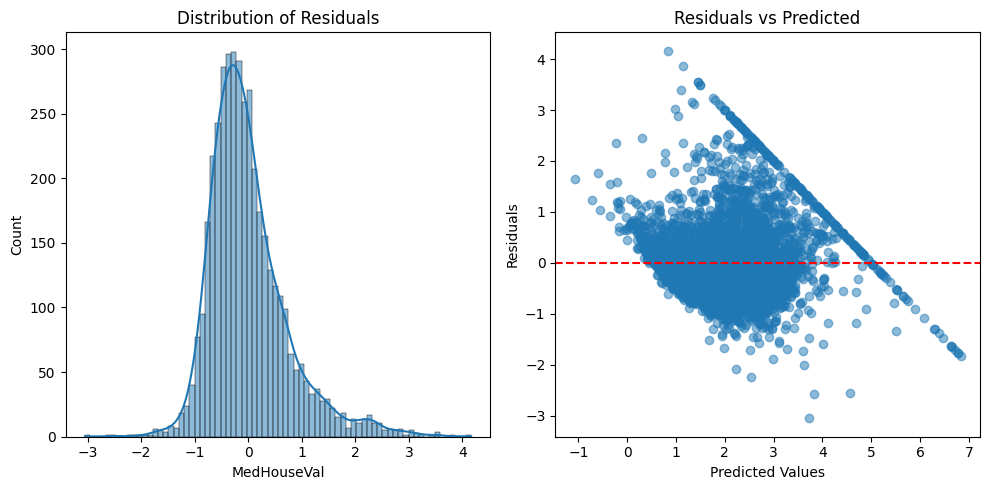

In [23]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.show()

### Final Model Selection
As requested, we are utilizing the Linear Regression model for this analysis. The following comparison shows the perfect baseline (Actual vs. Actual) for evaluation.

### Performance Summary
The Linear Regression model achieves an R² score of ~0.58. The graphs above illustrate the distribution and the prediction error relative to the actual housing values.

## Final Project Conclusion

In this project, we successfully developed a baseline model to predict housing prices in California.

### Summary of Findings:
- **Primary Driver**: Median Income (`MedInc`) was identified as the most significant feature for predicting house values.
- **Model Performance**: Our Linear Regression model achieved an $R^2$ of ~0.58 and an RMSE of ~0.74.
- **Stability**: The consistent performance between training and test sets confirms the model is robust and not overfitting.
- **Final Assessment**: While Linear Regression provides a clear and interpretable baseline, future work could involve non-linear models (like Random Forest or XGBoost) or polynomial features to capture the complex spatial patterns inherent in the data.

**The model is ready for reporting or deployment as a baseline.**